In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip install kagglehub[pandas-datasets]

Note: you may need to restart the kernel to use updated packages.


In [7]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load a DataFrame with a specific version of a CSV
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "vencerlanz09/lgbt-tweets",
    "LGBT_Tweets_processed.csv",
)

print(df.head(100),df.columns)
print(df["tweet"][0:100])

    Unnamed: 0        date      time                   id  \
0            0  2022-08-26  10:31:10  1562991009180827649   
1            1  2022-08-26  10:31:02  1562990976939229184   
2            3  2022-08-26  10:30:59  1562990965442326528   
3            7  2022-08-26  10:30:34  1562990860928659457   
4           10  2022-08-26  10:30:24  1562990819485032449   
..         ...         ...       ...                  ...   
95         376  2022-08-26  10:06:25  1562984783763763200   
96         379  2022-08-26  10:06:18  1562984753275760640   
97         392  2022-08-26  10:05:10  1562984466057818112   
98         399  2022-08-26  10:04:44  1562984358071668736   
99         400  2022-08-26  10:04:42  1562984350672908288   

                                                tweet language  replies_count  \
0                Praying for my lgbt Nigerians 🙏🏽🙏🏽🙏🏽       en              0   
1      @yanmisamm So pass agg omg you really are lgbt       en              0   
2   @ChampionExcel @wato

Questo codice pulisce i tweet per facilitarne l'analisi automatica, riducendo il rumore e migliorando la qualità dei dati.


In [25]:
import pandas as pd

# Copia del dataframe originale
data = df.copy()

# Preprocessing standard dei tweet
data['tweet'] = data['tweet'].str.lower()  # Minuscolo
data['tweet'] = data['tweet'].str.split().apply(
    lambda x: ' '.join([word for word in x if not word.startswith('@')])  # Rimuove gli handler
)
data['tweet'] = data['tweet'].str.split().apply(
    lambda x: ' '.join([word for word in x if not word.startswith('#')])  # Rimuove gli hashtag
)
data['tweet'] = data['tweet'].str.split().apply(
    lambda x: ' '.join([word for word in x if not word.startswith('http')])  # Rimuove URL
)
data['tweet'] = data['tweet'].str.split().apply(
    lambda x: ' '.join(word for word in x if word.isalnum())  # Rimuove caratteri speciali
)
data['tweet'] = data['tweet'].str.split().apply(
    lambda x: ' '.join(word for word in x if len(word) > 1)  # Rimuove singoli caratteri
)
data['tweet'] = data['tweet'].str.strip().replace(' +', ' ', regex=True)  # Rimuove spazi multipli

dataframe= data["tweet"][:300]

print(dataframe)


0                          praying for my lgbt nigerians
1                    so pass agg omg you really are lgbt
2      many working in the twitter and fb seem to whi...
3      to be clear it justify what the lgbt community...
4                              good night lgbt community
                             ...                        
295                           am yunhopower now you know
296    this is the same industry where person is call...
297         we need the lgbt youth needs to do something
298            oof just going after teenage me hard like
299    and the gov is doing jack shit on lgbt rights ...
Name: tweet, Length: 300, dtype: object


con spacy faccio POS e poi estraggo tutti i pronomi e per ogni pronome faccio un'analisi morfologica per vedere se il genere è maschile o femminile

In [67]:
import spacy
import en_core_web_sm
nlp=en_core_web_sm.load()


maschile = 0
femminile = 0
neutro = 0


for tweet in dataframe:
    doc = nlp(tweet)
    for token in doc:
        #print(token.text,token.pos_, token.dep_)
        if token.pos_ == "PRON":
            print(f"Token: {token.text}, POS: {token.pos_}")
            if token.pos_ == "PRON":
                gender = token.morph.get("Gender")
                print(f"Token: {token.text}, Genere: {gender}")
                if gender:
                    if gender[0] == "Masc":
                        maschile += 1
                    elif gender[0] == "Fem":
                        femminile += 1
                    else:
                        neutro += 1
                else:
                    neutro += 1  # Se Gender non è specificato []

print("Somma per genere:")
print("Maschili:", maschile)
print("Femminili:", femminile)
print("Neutri o non specificati:", neutro)
            


Token: my, POS: PRON
Token: my, Genere: []
Token: you, POS: PRON
Token: you, Genere: []
Token: which, POS: PRON
Token: which, Genere: []
Token: they, POS: PRON
Token: they, Genere: []
Token: them, POS: PRON
Token: them, Genere: []
Token: them, POS: PRON
Token: them, Genere: []
Token: it, POS: PRON
Token: it, Genere: ['Neut']
Token: what, POS: PRON
Token: what, Genere: []
Token: you, POS: PRON
Token: you, Genere: []
Token: what, POS: PRON
Token: what, Genere: []
Token: them, POS: PRON
Token: them, Genere: []
Token: i, POS: PRON
Token: i, Genere: []
Token: who, POS: PRON
Token: who, Genere: []
Token: my, POS: PRON
Token: my, Genere: []
Token: my, POS: PRON
Token: my, Genere: []
Token: you, POS: PRON
Token: you, Genere: []
Token: me, POS: PRON
Token: me, Genere: []
Token: who, POS: PRON
Token: who, Genere: []
Token: your, POS: PRON
Token: your, Genere: []
Token: we, POS: PRON
Token: we, Genere: []
Token: it, POS: PRON
Token: it, Genere: ['Neut']
Token: who, POS: PRON
Token: who, Genere: [

**grafico per rappresentare la distribuzione dei genere tramite un'analisi morfologica dei pronomi presenti nei tweet**

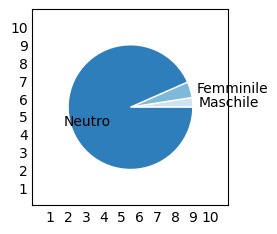

In [80]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery-nogrid')

# Dati dei generi
x = [15, 25, 567]
labels = ['Maschile', 'Femminile', 'Neutro']
colors = plt.get_cmap('Blues')(np.linspace(0.2, 0.7, len(x)))

# Grafico
fig, ax = plt.subplots()
ax.pie(x, labels=labels, colors=colors, radius=3.5, center=(5.5, 5.5),
       wedgeprops={"linewidth": 1, "edgecolor": "white"}, frame=True)

ax.set(xlim=(0, 11), xticks=np.arange(1, 11),
       ylim=(0, 11), yticks=np.arange(1,11))

plt.show()


analisi del sentiment

In [10]:
import pandas as pd

# Percorso del file
file_path = '/kaggle/input/lexicon/subjclueslen1-HLTEMNLP05.tff'

# Leggi e processa il file riga per riga
data = []
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        entry = dict(item.split('=') for item in line.strip().split() if '=' in item)
        data.append(entry)

# Crea un DataFrame
df = pd.DataFrame(data)

# Mostra le prime righe
#df.head()
words= df[['word1', 'priorpolarity']]
words


,word1,priorpolarity
0,abandoned,negative
1,abandonment,negative
2,abandon,negative
3,abase,negative
4,abasement,negative
...,...,...
8217,zealot,negative
8218,zealous,negative
8219,zealously,negative
8220,zenith,positive


lista parole positive

In [16]:
# Filtro: solo le righe dove priorpolarity è "positive"
positive_words = df[df['priorpolarity'] == 'positive']

# Mostra solo la colonna 'word1'
positive_list = positive_words['word1'].tolist()

# Visualizza le prime parole positive
print(positive_list[:200])


['abidance', 'abidance', 'abide', 'abilities', 'ability', 'able', 'above', 'above-average', 'abound', 'absolve', 'abundant', 'abundance', 'accede', 'accept', 'acceptance', 'acceptable', 'accessible', 'acclaim', 'acclaim', 'acclaimed', 'acclamation', 'accolade', 'accolades', 'accommodative', 'accomplish', 'accomplishment', 'accomplishments', 'accord', 'accordance', 'accordantly', 'accurate', 'accurately', 'achievable', 'achieve', 'achievement', 'achievements', 'acknowledge', 'acknowledgement', 'acquit', 'active', 'acumen', 'adaptable', 'adaptability', 'adaptive', 'adept', 'adeptly', 'adequate', 'adherence', 'adherent', 'adhesion', 'admirable', 'admirer', 'admirable', 'admirably', 'admiration', 'admire', 'admiring', 'admiringly', 'admission', 'admission', 'admit', 'admittedly', 'adorable', 'adore', 'adored', 'adorer', 'adorer', 'adoring', 'adoringly', 'adroit', 'adroitly', 'adulate', 'adulation', 'adulatory', 'advanced', 'advantage', 'advantage', 'advantageous', 'advantages', 'advantages

In [ ]:
embedding parole positive

In [23]:
from sentence_transformers import SentenceTransformer

# Carica un modello pre-addestrato (scegline uno compatibile con la tua lingua)
model = SentenceTransformer('multi-qa-mpnet-base-dot-v1') 
embeddings_positive = model.encode(positive_list)
print("emb1:",embeddings_positive)

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

emb1: [[-0.15278223 -0.72750604 -0.22803506 ...  0.17000458 -0.09115337
   0.15749647]
 [-0.15278223 -0.72750604 -0.22803506 ...  0.17000458 -0.09115337
   0.15749647]
 [-0.2748808  -0.5472787  -0.2625132  ...  0.10541866 -0.07418385
   0.0101507 ]
 ...
 [-0.16324854 -0.70711696 -0.26900175 ...  0.17166676 -0.09771252
  -0.04473027]
 [ 0.19435349 -0.55310404 -0.18281631 ... -0.15450709 -0.44647354
  -0.09589405]
 [-0.29545704 -1.2850932  -0.28181174 ...  0.20026915 -0.10746136
  -0.04197925]]


In [ ]:
lista parole negative

In [20]:
# Filtro: solo le righe dove priorpolarity è "positive"
negative_words = df[df['priorpolarity'] == 'negative']

# Mostra solo la colonna 'word1'
negative_list = negative_words['word1'].tolist()

# Visualizza le prime parole positive
print(negative_list[:200])


['abandoned', 'abandonment', 'abandon', 'abase', 'abasement', 'abash', 'abate', 'abdicate', 'aberration', 'aberration', 'abhor', 'abhor', 'abhorred', 'abhorrence', 'abhorrent', 'abhorrently', 'abhors', 'abhors', 'abject', 'abjectly', 'abjure', 'abnormal', 'abolish', 'abominable', 'abominably', 'abominate', 'abomination', 'abrade', 'abrasive', 'abrupt', 'abscond', 'absence', 'absentee', 'absent-minded', 'absurd', 'absurdity', 'absurdly', 'absurdness', 'abuse', 'abuse', 'abuse', 'abuses', 'abuses', 'abusive', 'abysmal', 'abysmally', 'abyss', 'accidental', 'accost', 'accountable', 'accursed', 'accusation', 'accusation', 'accusations', 'accusations', 'accuse', 'accuses', 'accusing', 'accusingly', 'acerbate', 'acerbic', 'acerbically', 'ache', 'acrid', 'acridly', 'acridness', 'acrimonious', 'acrimoniously', 'acrimony', 'adamant', 'adamantly', 'addict', 'addiction', 'admonish', 'admonisher', 'admonishingly', 'admonishment', 'admonition', 'adrift', 'adulterate', 'adulterated', 'adulteration', 

embedding parole negative

In [24]:
embeddings_negative = model.encode(negative_list)
print("emb2:",embeddings_negative)

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

emb2: [[-0.06236677 -0.18364204 -0.3098103  ... -0.12459594 -0.29122385
   0.38266695]
 [-0.082072   -0.451032   -0.3541649  ...  0.07976124 -0.00741136
   0.41263658]
 [-0.33864963 -0.3133464  -0.3076906  ... -0.08782253 -0.12981287
   0.27511594]
 ...
 [-0.15971732 -0.70867944 -0.31068224 ...  0.20735042 -0.06065706
  -0.021389  ]
 [-0.18759018 -0.861224   -0.28956944 ...  0.27472252  0.02093573
  -0.01083746]
 [-0.15681997 -0.64097244 -0.2835576  ... -0.02428469 -0.24021986
  -0.1994558 ]]


embedding tweet

In [29]:
import pandas as pd

# Percorso al file
file_path = '/kaggle/input/lgbt-tweets/LGBT_Tweets_processed.csv'

# Leggi il CSV
df = pd.read_csv(file_path)

# Mostra le prime 5 righe
#df.head()
tweet = df["tweet"][:100]
tweet


0                  Praying for my lgbt Nigerians 🙏🏽🙏🏽🙏🏽
1        @yanmisamm So pass agg omg you really are lgbt
2     @ChampionExcel @watokohom @MrAndyNgo @football...
3     To be clear it doesn't justify what the LGBT c...
4     good night lgbt community  https://t.co/0PAMOU...
                            ...                        
95    Bisexuality is someone saying you're not oppre...
96    The Catholic School the LGBt+ Pipeline will ne...
97    I literally feel Brianna be reaching just to s...
98    God, there was a user who had a highly liked c...
99    @Am_Notnero @ThunderRemix8 @lilbuzzach Yea yea...
Name: tweet, Length: 100, dtype: object

embedding tweet

In [31]:
embeddings_tweet= model.encode(tweet)
print("emb3:",embeddings_tweet)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

emb3: [[-0.04072595 -0.26593736 -0.54410124 ... -0.00291908  0.10914633
  -0.12119153]
 [-0.12435966 -0.46762338 -0.41117296 ...  0.05432771  0.12448406
  -0.17165318]
 [ 0.04641426 -0.10135056 -0.29314464 ...  0.19913653  0.34773594
  -0.13346721]
 ...
 [-0.15748985 -0.23609628 -0.31113762 ... -0.00851357 -0.09919468
  -0.21301863]
 [ 0.2799683  -0.06925573 -0.26751435 ...  0.09394929  0.11378236
  -0.05111783]
 [ 0.00801414 -0.24829437 -0.31165177 ...  0.25419933  0.01896905
  -0.1468177 ]]


cos_sim

In [34]:
from sentence_transformers.util import cos_sim 

sim1= cos_sim(embeddings_tweet, embeddings_positive)
print(sim1)
sim2= cos_sim(embeddings_tweet, embeddings_negative)
print(sim2)

tensor([[0.2411, 0.2411, 0.3106,  ..., 0.2894, 0.3065, 0.2448],
        [0.3652, 0.3652, 0.4284,  ..., 0.3212, 0.2962, 0.3154],
        [0.0931, 0.0931, 0.2171,  ..., 0.2713, 0.1775, 0.2294],
        ...,
        [0.2305, 0.2305, 0.2140,  ..., 0.2417, 0.2321, 0.2243],
        [0.2242, 0.2242, 0.3703,  ..., 0.2268, 0.1686, 0.2213],
        [0.3198, 0.3198, 0.2558,  ..., 0.2502, 0.2097, 0.2619]])
tensor([[0.2759, 0.2468, 0.2492,  ..., 0.3828, 0.3588, 0.2825],
        [0.3777, 0.3357, 0.3470,  ..., 0.4206, 0.3803, 0.3079],
        [0.2584, 0.2585, 0.2292,  ..., 0.3403, 0.3205, 0.2906],
        ...,
        [0.2254, 0.2523, 0.2063,  ..., 0.2846, 0.3045, 0.2367],
        [0.3507, 0.3525, 0.2977,  ..., 0.3526, 0.3485, 0.2757],
        [0.3052, 0.3153, 0.2844,  ..., 0.3914, 0.3624, 0.2429]])


In [38]:
from sentence_transformers import util
import numpy as np

# Media delle similarità
mean_sim_pos = sim1.mean().item()
mean_sim_neg = sim2.mean().item()

# Confronto
print(f"Media similarità con parole positive: {mean_sim_pos:.4f}")
print(f"Media similarità con parole negative: {mean_sim_neg:.4f}")

if mean_sim_pos > mean_sim_neg:
    print("Il tweet è semanticamente più vicino al linguaggio positivo.")
else:
    print("Il tweet è semanticamente più vicino al linguaggio negativo.")

Media similarità con parole positive: 0.2552
Media similarità con parole negative: 0.2589
Il tweet è semanticamente più vicino al linguaggio negativo.


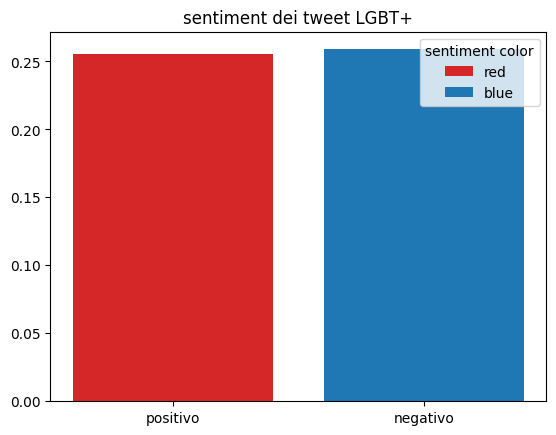

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

fruits = ['positivo', 'negativo']
counts = [0.2552, 0.2589]
bar_labels = ['red', 'blue']
bar_colors = ['tab:red', 'tab:blue']

ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

ax.set_title('sentiment dei tweet LGBT+')
ax.legend(title='sentiment color')

plt.show()